# 5. ML Diagnostic Engine — Predicting Query Performance

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

DATA_DIR = r"A:\pc\Desktop\Code\data science\sadop\Data"

# 5.1 Load Preprocessed Data

In [2]:
X_train = pd.read_csv(rf"{DATA_DIR}\X_train.csv")
X_test  = pd.read_csv(rf"{DATA_DIR}\X_test.csv")
y_train = pd.read_csv(rf"{DATA_DIR}\y_train.csv").squeeze()
y_test  = pd.read_csv(rf"{DATA_DIR}\y_test.csv").squeeze()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print(f"\nClass balance (test):\n{y_test.value_counts(normalize=True).round(3)}")


X_train: (15980, 12)
X_test : (3995, 12)

Class balance (test):
is_slow
0    0.561
1    0.439
Name: proportion, dtype: float64


# 5.2 Define All Models

In [ ]:
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from xgboost                 import XGBClassifier

MODELS = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),  
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),
}

print("Models defined ✅")
for name in MODELS:
    print(f"  - {name}")



Models defined ✅
  - Logistic Regression
  - Random Forest
  - XGBoost


# 5.3 Train All Models

In [4]:
trained = {}

for name, model in MODELS.items():
    print(f"⏳ Training {name} …", end=" ")
    model.fit(X_train, y_train)
    trained[name] = model
    print("done ✅")



⏳ Training Logistic Regression … done ✅
⏳ Training Random Forest … done ✅
⏳ Training XGBoost … done ✅


In [5]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, RocCurveDisplay
)

results = []

for name, model in trained.items():
    y_pred      = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model":     name,
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall":    recall_score(y_test, y_pred),
        "F1 Score":  f1_score(y_test, y_pred),
        "ROC-AUC":   roc_auc_score(y_test, y_pred_prob),
    })

results_df = pd.DataFrame(results).set_index("Model").round(4)
print("\n📊 Model Comparison:\n")
print(results_df.to_string())



📊 Model Comparison:

                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression    0.9589     0.9354  0.9738    0.9542   0.9944
Random Forest          0.9845     0.9942  0.9704    0.9821   0.9975
XGBoost                0.9832     0.9901  0.9715    0.9807   0.9975


# 5.4 Metrics Bar Chart Comparison

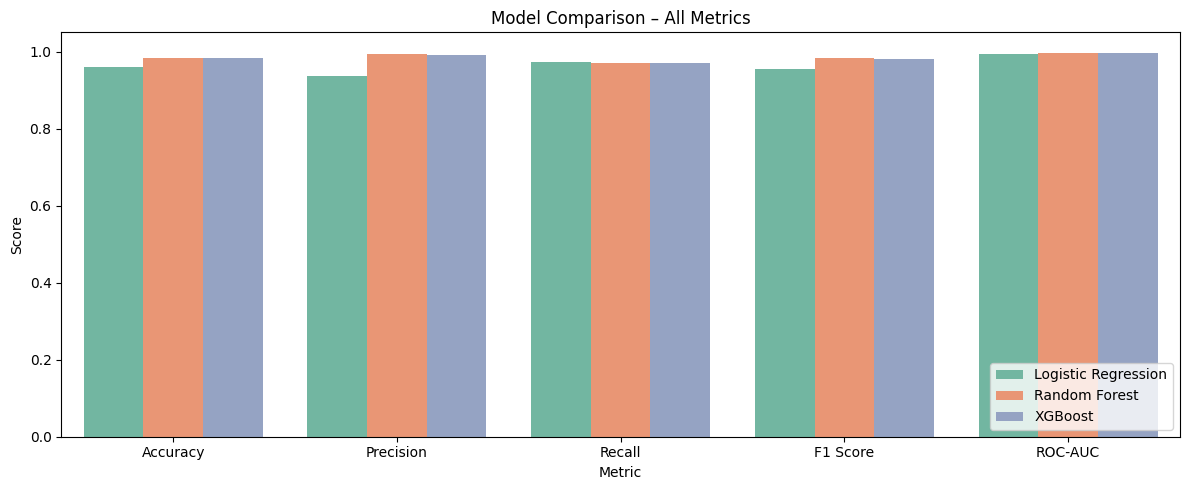

In [6]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
plot_df = results_df[metrics_to_plot].reset_index().melt(
    id_vars="Model", var_name="Metric", value_name="Score"
)

plt.figure(figsize=(12, 5))
sns.barplot(data=plot_df, x="Metric", y="Score", hue="Model", palette="Set2")
plt.title("Model Comparison – All Metrics")
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# 5.6  ROC Curves (all 3 on same plot)

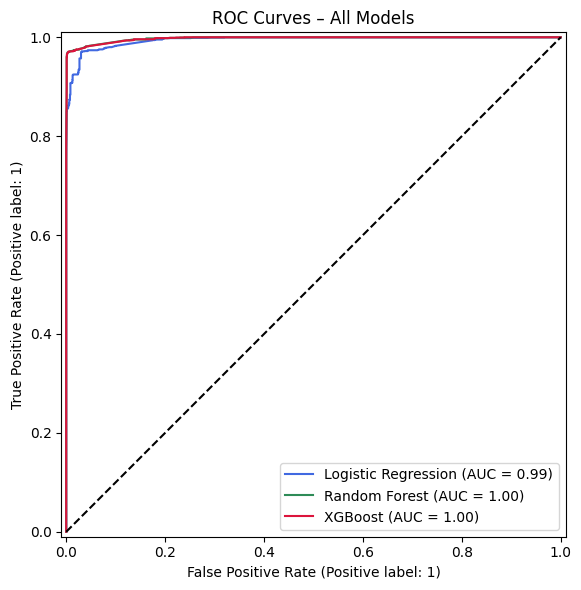

In [7]:
plt.figure(figsize=(7, 6))
ax = plt.gca()

colors = {"Logistic Regression": "royalblue", "Random Forest": "seagreen", "XGBoost": "crimson"}
for name, model in trained.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name, ax=ax, color=colors[name])

plt.plot([0, 1], [0, 1], "k--", label="Random baseline")
plt.title("ROC Curves – All Models")
plt.tight_layout()
plt.show()


# 5.6 Confusion Matrices (side by side)

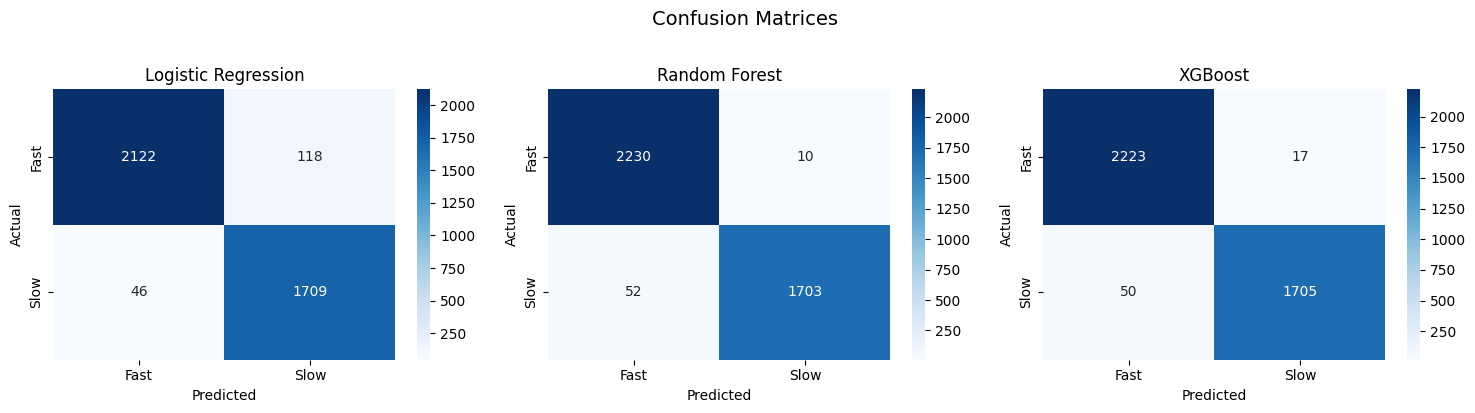

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, trained.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Fast", "Slow"],
                yticklabels=["Fast", "Slow"])
    ax.set_title(f"{name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


# 5.6 Classification Reports

In [9]:
for name, model in trained.items():
    y_pred = model.predict(X_test)
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(classification_report(y_test, y_pred, target_names=["Fast", "Slow"]))



  Logistic Regression
              precision    recall  f1-score   support

        Fast       0.98      0.95      0.96      2240
        Slow       0.94      0.97      0.95      1755

    accuracy                           0.96      3995
   macro avg       0.96      0.96      0.96      3995
weighted avg       0.96      0.96      0.96      3995


  Random Forest
              precision    recall  f1-score   support

        Fast       0.98      1.00      0.99      2240
        Slow       0.99      0.97      0.98      1755

    accuracy                           0.98      3995
   macro avg       0.99      0.98      0.98      3995
weighted avg       0.98      0.98      0.98      3995


  XGBoost
              precision    recall  f1-score   support

        Fast       0.98      0.99      0.99      2240
        Slow       0.99      0.97      0.98      1755

    accuracy                           0.98      3995
   macro avg       0.98      0.98      0.98      3995
weighted avg       0.98

# 5.8 Feature Importance (RF & XGBoost)
#           Coefficients (Logistic Regression)

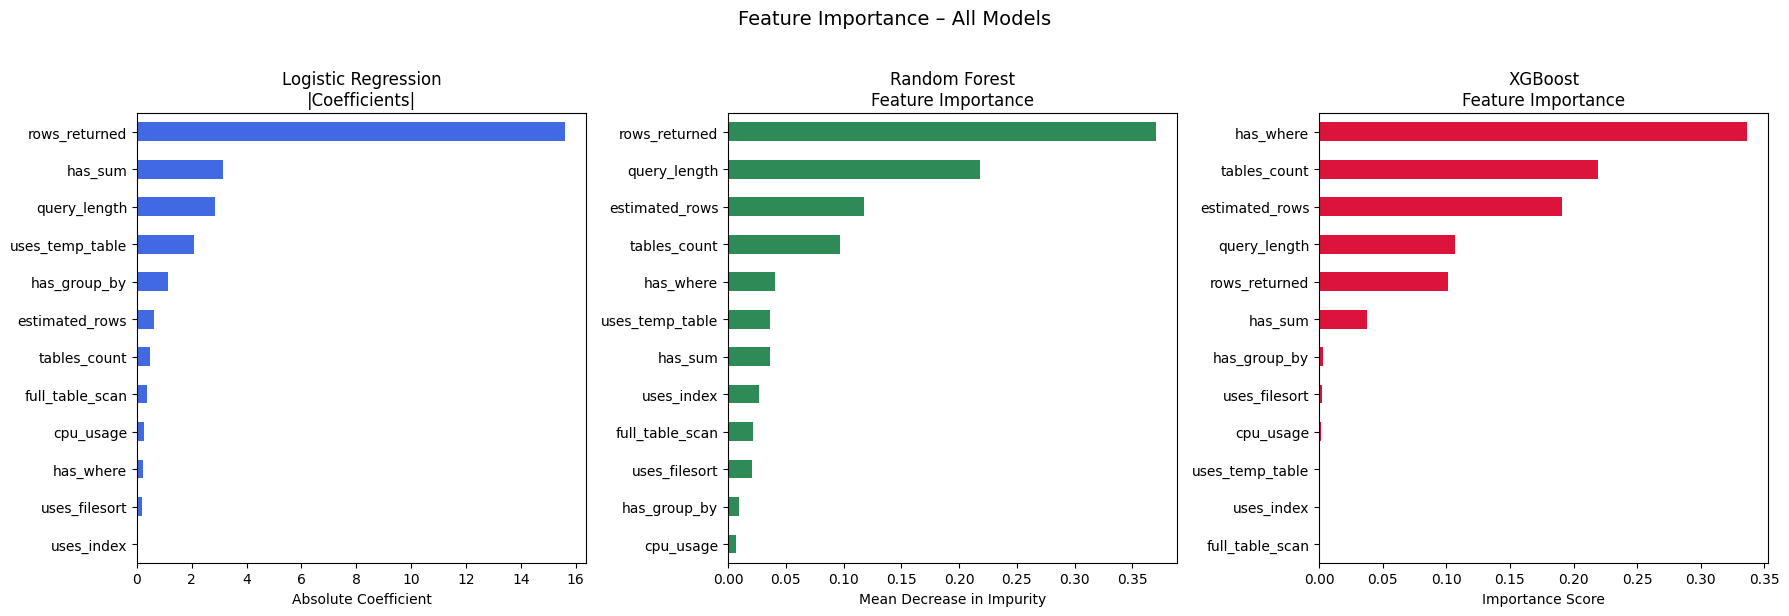

In [13]:
FEATURES = X_train.columns.tolist()
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Logistic Regression – coefficients
lr_coef = pd.Series(
    np.abs(trained["Logistic Regression"].coef_[0]),
    index=FEATURES
).sort_values(ascending=True)
lr_coef.plot(kind="barh", ax=axes[0], color="royalblue")
axes[0].set_title("Logistic Regression\n|Coefficients|")
axes[0].set_xlabel("Absolute Coefficient")

# Random Forest – feature importance
rf_imp = pd.Series(
    trained["Random Forest"].feature_importances_,
    index=FEATURES
).sort_values(ascending=True)
rf_imp.plot(kind="barh", ax=axes[1], color="seagreen")
axes[1].set_title("Random Forest\nFeature Importance")
axes[1].set_xlabel("Mean Decrease in Impurity")

xgb_imp = pd.Series(
    trained["XGBoost"].feature_importances_,
    index=FEATURES
).sort_values(ascending=True)
xgb_imp.plot(kind="barh", ax=axes[2], color="crimson")
axes[2].set_title("XGBoost\nFeature Importance")
axes[2].set_xlabel("Importance Score")

plt.suptitle("Feature Importance – All Models", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


# 5.9 Best Model 

In [12]:
best_model_name = results_df["F1 Score"].idxmax()
best_row        = results_df.loc[best_model_name]

print("🏆 Best Model by F1 Score")
print(f"   Model    : {best_model_name}")
print(f"   F1 Score : {best_row['F1 Score']:.4f}")
print(f"   ROC-AUC  : {best_row['ROC-AUC']:.4f}")
print(f"   Accuracy : {best_row['Accuracy']:.4f}")
print(f"   Recall   : {best_row['Recall']:.4f}")


🏆 Best Model by F1 Score
   Model    : Random Forest
   F1 Score : 0.9821
   ROC-AUC  : 0.9975
   Accuracy : 0.9845
   Recall   : 0.9704


# 5.10 Export Models 

In [14]:
import pickle
import os

MODELS_DIR = rf"{DATA_DIR}\models V2"
os.makedirs(MODELS_DIR, exist_ok=True)

FILE_NAMES = {
    "Logistic Regression": "logistic_regression.pkl",
    "Random Forest":       "random_forest.pkl",
    "XGBoost":             "xgboost.pkl",
}

for name, model in trained.items():
    path = os.path.join(MODELS_DIR, FILE_NAMES[name])
    with open(path, "wb") as f:
        pickle.dump(model, f)
    print(f"✅ {name} saved → {path}")

print(f"\n📦 All models exported to: {MODELS_DIR}")


✅ Logistic Regression saved → A:\pc\Desktop\Code\data science\sadop\Data\models V2\logistic_regression.pkl
✅ Random Forest saved → A:\pc\Desktop\Code\data science\sadop\Data\models V2\random_forest.pkl
✅ XGBoost saved → A:\pc\Desktop\Code\data science\sadop\Data\models V2\xgboost.pkl

📦 All models exported to: A:\pc\Desktop\Code\data science\sadop\Data\models V2
